# 02c — EDA: Phân khúc khách hàng

Phần 3/4 của EDA (tách từ `02_eda.ipynb` gốc — xem `docs/analysis/EDA_FINDINGS.md` cho phân tích đầy đủ). Phạm vi: demographics theo tuổi, RFM segmentation, cohort retention (gồm phát hiện lỗi `signup_date` + kiểm định giả thuyết mùa vụ).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # notebook vẫn hiện inline qua %matplotlib inline bên dưới
import matplotlib.pyplot as plt
from lunardate import LunarDate

from datathon import config
from datathon.ingestion import load_raw

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("DATA_RAW:", config.DATA_RAW)


DATA_RAW: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


In [2]:
import os
import trino

_trino_conn = trino.dbapi.connect(
    host=os.environ.get("TRINO_HOST", "localhost"),
    port=int(os.environ.get("TRINO_PORT", "8080")),
    user="notebook_02_eda",
    catalog="iceberg",
    schema="staging",
)
sales = pd.read_sql(
    "SELECT date AS \"Date\", revenue AS \"Revenue\", cogs AS \"COGS\" "
    "FROM mart_revenue_daily ORDER BY date",
    _trino_conn,
)
sales["Date"] = pd.to_datetime(sales["Date"])
assert len(sales) == 3833, f"mart_revenue_daily phải 3833 dòng, đang {len(sales)}"
orders = load_raw("orders")
items = load_raw("order_items")
products = load_raw("products")
customers = load_raw("customers")
geography = load_raw("geography")
promotions = load_raw("promotions")
returns = load_raw("returns")
payments = load_raw("payments")

for name, df in [("sales", sales), ("orders", orders), ("order_items", items),
                  ("products", products), ("customers", customers),
                  ("geography", geography), ("promotions", promotions),
                  ("returns", returns), ("payments", payments)]:
    print(f"{name:14s} {df.shape}")


sales          (3833, 3)
orders         (646945, 8)
order_items    (714669, 7)
products       (2412, 8)
customers      (121930, 7)
geography      (39948, 4)
promotions     (50, 10)
returns        (39939, 7)
payments       (646945, 4)


In [3]:
# customers đã có sẵn cột 'zip' (khác bản gốc chỉ usecols acquisition_channel/signup_date) ->
# drop trước khi merge để tránh đụng 'zip' đã có từ orders (tránh bị pandas tự suffix zip_x/zip_y).
customers_nozip = customers.drop(columns=["zip"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers_nozip, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
sales_idx = sales.set_index("Date")["Revenue"]
diff = ((chk.reindex(sales_idx.index) - sales_idx).abs() / sales_idx).mean() * 100
print(f"Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
print(f"{len(li):,} dòng sau join, {li['customer_id'].nunique():,} khách")


Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: 0.000% (kỳ vọng ~0%)
677,662 dòng sau join, 89,063 khách


## Demographics theo tuổi (`li`)

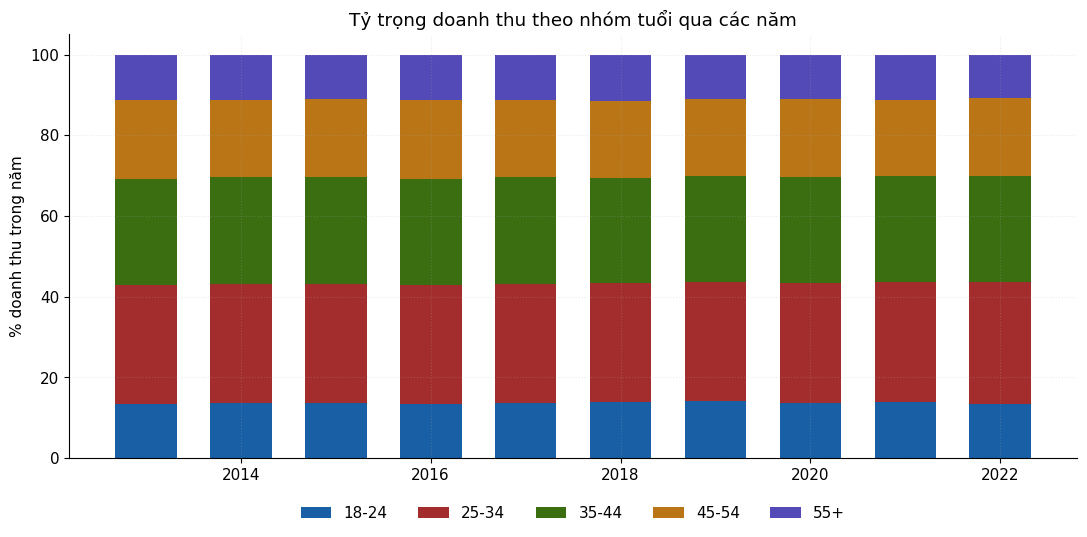

In [4]:
li["age_group"] = pd.Categorical(li["age_group"], categories=AGE_ORDER, ordered=True)
age_yr = li.groupby(["year", "age_group"], observed=True)["line_revenue"].sum().unstack()
age_share = age_yr.div(age_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(age_share))
for i, ag in enumerate(AGE_ORDER):
    ax.bar(age_share.index, age_share[ag], bottom=bottom, label=ag,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += age_share[ag].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo nhóm tuổi qua các năm")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); plt.show()


Cơ cấu tuổi gần như bất động suốt 10 năm (biến động dưới 0.8 điểm %/nhóm) — loại trừ giả thuyết mất 1 nhóm tuổi cụ thể gây sụt doanh thu.

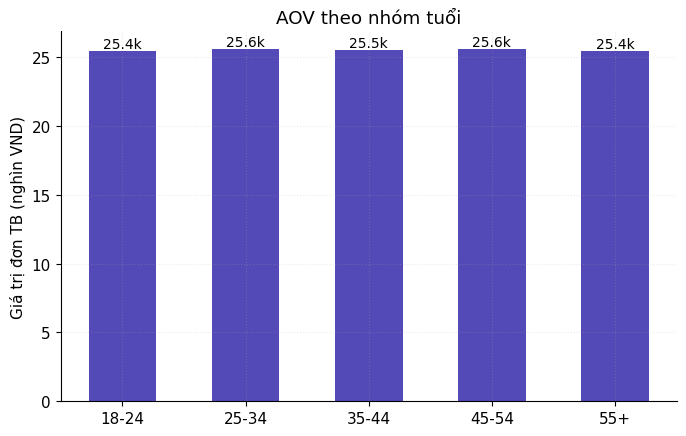

AOV theo tuổi (nghìn VND): {'18-24': 25.42, '25-34': 25.56, '35-44': 25.5, '45-54': 25.59, '55+': 25.42}


In [5]:
order_val_age = li.groupby(["order_id", "age_group"], observed=True)["line_revenue"].sum().reset_index()
aov_age = order_val_age.groupby("age_group", observed=True)["line_revenue"].mean().reindex(AGE_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(aov_age.index, aov_age.values / 1e3, color=C_ACCENT, width=0.55)
for i, v in enumerate(aov_age.values / 1e3):
    ax.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax.set_title("AOV theo nhóm tuổi")
fig.tight_layout(); plt.show()
print("AOV theo tuổi (nghìn VND):", (aov_age / 1e3).round(2).to_dict())


AOV đồng đều mọi nhóm tuổi (25.4-25.6 nghìn VND, chênh dưới 1%) — tuổi không phân biệt hành vi chi tiêu trong dataset này.

## RFM Segmentation

In [6]:
SNAPSHOT_DATE = orders["order_date"].max()
non_cancel = orders[orders["order_status"] != "cancelled"].merge(
    payments[["order_id", "payment_value"]], on="order_id", how="left")

rfm = non_cancel.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()
rfm["recency_days"] = (SNAPSHOT_DATE - rfm["last_order"]).dt.days

def qscore(s, labels):
    ranks = s.rank(method="first")
    return pd.qcut(ranks, 5, labels=labels).astype(int)

rfm["R_score"] = qscore(rfm["recency_days"], [5, 4, 3, 2, 1])
rfm["F_score"] = qscore(rfm["frequency"], [1, 2, 3, 4, 5])
rfm["M_score"] = qscore(rfm["monetary"], [1, 2, 3, 4, 5])

def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New Customers"
    if r == 3 and f <= 2: return "Promising"
    if r <= 2 and f >= 4 and m >= 4: return "Can't Lose Them"
    if r <= 2 and f >= 3: return "At Risk"
    if r <= 2 and f <= 2 and m >= 3: return "Hibernating"
    if r <= 2 and f <= 2: return "Lost"
    return "Need Attention"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)
seg_summary = (rfm.groupby("segment")
               .agg(n_customers=("customer_id", "count"),
                    total_monetary=("monetary", "sum"),
                    avg_recency=("recency_days", "mean"),
                    avg_frequency=("frequency", "mean"))
               .sort_values("total_monetary", ascending=False))
seg_summary["pct_customers"] = seg_summary["n_customers"] / seg_summary["n_customers"].sum() * 100
seg_summary["pct_monetary"] = seg_summary["total_monetary"] / seg_summary["total_monetary"].sum() * 100
seg_summary.round(2)


,n_customers,total_monetary,avg_recency,avg_frequency,pct_customers,pct_monetary
segment,,,,,,
Champions,22575,8.949596e+09,274.23,15.88,25.62,62.88
Loyal Customers,16974,2.884125e+09,787.01,7.02,19.26,20.26
At Risk,7989,6.461639e+08,2009.51,3.90,9.07,4.54
Can't Lose Them,2251,4.920698e+08,1782.76,8.61,2.55,3.46
Lost,21682,4.587557e+08,2562.65,1.26,24.60,3.22
Hibernating,3327,2.696038e+08,2398.74,1.60,3.78,1.89
Promising,5375,2.054179e+08,1105.38,1.48,6.10,1.44
New Customers,4865,2.033228e+08,359.00,1.51,5.52,1.43
Need Attention,3085,1.248016e+08,688.95,3.65,3.50,0.88


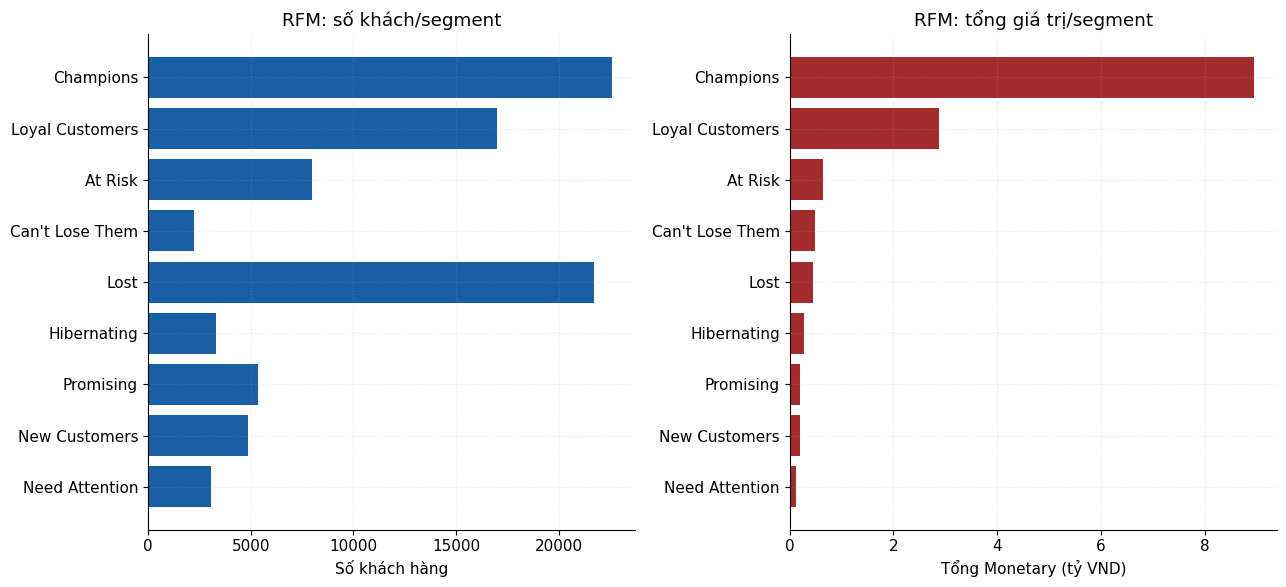

In [7]:
order_idx = seg_summary.index
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(order_idx, seg_summary["n_customers"], color=PALETTE[0])
axes[0].invert_yaxis(); axes[0].set_xlabel("Số khách hàng"); axes[0].set_title("RFM: số khách/segment")
axes[1].barh(order_idx, seg_summary["total_monetary"] / 1e9, color=PALETTE[1])
axes[1].invert_yaxis(); axes[1].set_xlabel("Tổng Monetary (tỷ VND)"); axes[1].set_title("RFM: tổng giá trị/segment")
fig.tight_layout(); plt.show()


Champions 25.6% khách nhưng nắm 62.9% giá trị; Lost 24.6% khách (gần bằng Champions về số lượng) chỉ còn 3.2% giá trị — phân bổ giá trị cực lệch.

## Cohort Retention

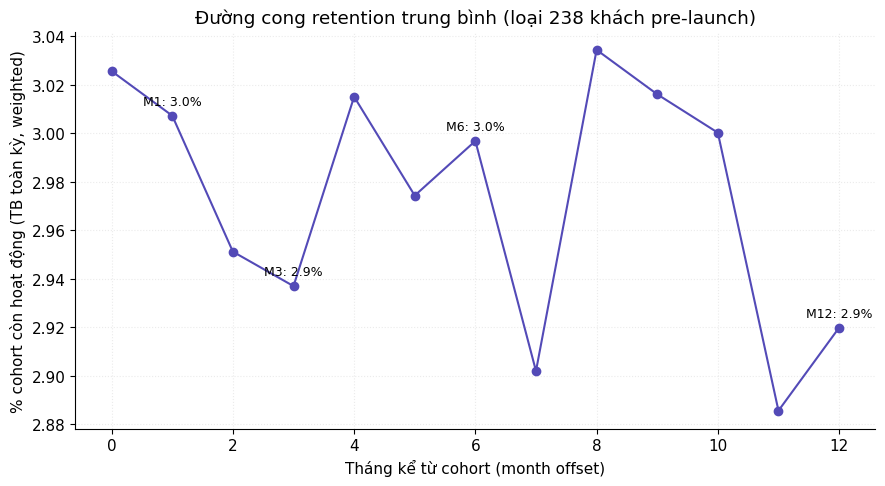

Retention mốc: {'M1': 3.0, 'M3': 2.9, 'M6': 3.0, 'M12': 2.9}
Cohort chính: 121,692 khách, 126 cohort tháng


In [8]:
SHOP_OPEN = pd.Timestamp("2012-07-04")
customers_full = customers.copy()
customers_full["signup_date"] = pd.to_datetime(customers_full["signup_date"])
is_pre_launch = customers_full["signup_date"] < SHOP_OPEN
pre_launch = customers_full[is_pre_launch].copy()
cohort_customers = customers_full[~is_pre_launch].copy()
cohort_customers["cohort_month"] = cohort_customers["signup_date"].dt.to_period("M")

orders_nc = non_cancel[["customer_id", "order_date"]].copy()
orders_nc["order_month"] = orders_nc["order_date"].dt.to_period("M")

merged = orders_nc.merge(cohort_customers[["customer_id", "cohort_month"]], on="customer_id", how="inner")
merged["month_offset"] = ((merged["order_month"].dt.year - merged["cohort_month"].dt.year) * 12
                           + (merged["order_month"].dt.month - merged["cohort_month"].dt.month))
merged = merged[merged["month_offset"] >= 0]

cohort_sizes = cohort_customers.groupby("cohort_month")["customer_id"].nunique()
active = merged.groupby(["cohort_month", "month_offset"])["customer_id"].nunique().unstack()

max_month = orders_nc["order_month"].max()
avg_retention = {}
for off in range(0, 13):
    eligible = cohort_sizes.index[cohort_sizes.index + off <= max_month]
    denom = cohort_sizes.loc[eligible].sum()
    numer = active.reindex(index=eligible, columns=[off]).fillna(0).sum().iloc[0] if off in active.columns else 0
    avg_retention[off] = numer / denom * 100 if denom > 0 else np.nan
avg_retention = pd.Series(avg_retention)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(avg_retention.index, avg_retention.values, marker="o", color=C_ACCENT)
for m in [1, 3, 6, 12]:
    if m in avg_retention.index:
        ax.annotate(f"M{m}: {avg_retention[m]:.1f}%", (m, avg_retention[m]),
                    textcoords="offset points", xytext=(0, 8), fontsize=9, ha="center")
ax.set_xlabel("Tháng kể từ cohort (month offset)")
ax.set_ylabel("% cohort còn hoạt động (TB toàn kỳ, weighted)")
ax.set_title(f"Đường cong retention trung bình (loại {len(pre_launch)} khách pre-launch)")
fig.tight_layout(); plt.show()

print("Retention mốc:", {f"M{k}": round(v, 1) for k, v in avg_retention.items() if k in [1, 3, 6, 12]})
print(f"Cohort chính: {len(cohort_customers):,} khách, {cohort_sizes.shape[0]} cohort tháng")


LỖI DỮ LIỆU đã phát hiện: `signup_date` không phản ánh quan hệ mua bán thật (89.3% khách có đơn TRƯỚC ngày signup). Retention 'phẳng ~3%' đo ở đây chỉ là base rate ngẫu nhiên, KHÔNG PHẢI retention thật — xem chart kế tiếp.

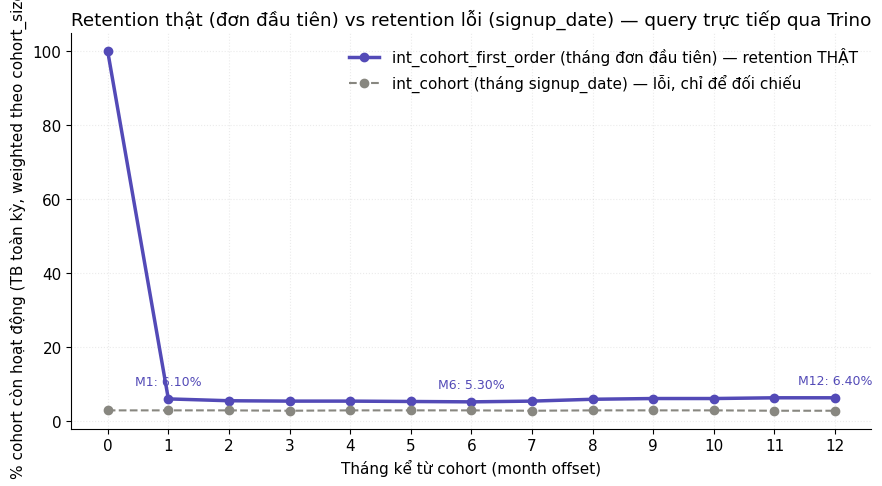

int_cohort_first_order — retention mốc: {'M0': 100.0, 'M1': 6.1, 'M3': 5.5, 'M6': 5.3, 'M9': 6.2, 'M12': 6.4}
int_cohort (signup, đối chiếu) — retention mốc: {'M0': 3.0, 'M1': 3.0, 'M3': 2.9, 'M6': 3.0, 'M9': 3.0, 'M12': 2.9}
Đáy 'nụ cười': M6 = 5.30%  |  hồi tới M12 = 6.40%
Tỷ lệ retention thật / retention lỗi: M1=2.03x, M6=1.77x, M12=2.21x


In [9]:
cohort_true = pd.read_sql(
    "SELECT month_offset, SUM(n_active) * 100.0 / SUM(cohort_size) AS retention_pct "
    "FROM int_cohort_first_order WHERE month_offset BETWEEN 0 AND 12 "
    "GROUP BY month_offset ORDER BY month_offset",
    _trino_conn,
).set_index("month_offset")["retention_pct"].astype(float)

cohort_signup = pd.read_sql(
    "SELECT month_offset, SUM(n_active) * 100.0 / SUM(cohort_size) AS retention_pct "
    "FROM int_cohort WHERE month_offset BETWEEN 0 AND 12 "
    "GROUP BY month_offset ORDER BY month_offset",
    _trino_conn,
).set_index("month_offset")["retention_pct"].astype(float)

assert len(cohort_true) == 13 and len(cohort_signup) == 13, "phai du 13 diem M0..M12"
assert cohort_true.loc[0] == 100.0, "M0 phai = 100% theo dinh nghia (moi khach active thang vao cohort)"

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cohort_true.index, cohort_true.values, marker="o", color=C_ACCENT, lw=2.5,
        label="int_cohort_first_order (tháng đơn đầu tiên) — retention THẬT")
ax.plot(cohort_signup.index, cohort_signup.values, marker="o", color=C_GRAY, lw=1.5, linestyle="--",
        label="int_cohort (tháng signup_date) — lỗi, chỉ để đối chiếu")
for m in [1, 6, 12]:
    ax.annotate(f"M{m}: {cohort_true.loc[m]:.2f}%", (m, cohort_true.loc[m]),
                textcoords="offset points", xytext=(0, 10), fontsize=9, ha="center", color=C_ACCENT)
ax.set_xlabel("Tháng kể từ cohort (month offset)")
ax.set_ylabel("% cohort còn hoạt động (TB toàn kỳ, weighted theo cohort_size)")
ax.set_title("Retention thật (đơn đầu tiên) vs retention lỗi (signup_date) — query trực tiếp qua Trino")
ax.set_xticks(range(0, 13))
ax.legend(frameon=False, loc="upper right")
fig.tight_layout(); plt.show()

print("int_cohort_first_order — retention mốc:",
      {f"M{k}": round(v, 2) for k, v in cohort_true.items() if k in [0, 1, 3, 6, 9, 12]})
print("int_cohort (signup, đối chiếu) — retention mốc:",
      {f"M{k}": round(v, 2) for k, v in cohort_signup.items() if k in [0, 1, 3, 6, 9, 12]})
print(f"Đáy 'nụ cười': M{cohort_true.idxmin()} = {cohort_true.min():.2f}%  |  hồi tới M12 = {cohort_true.loc[12]:.2f}%")
print(f"Tỷ lệ retention thật / retention lỗi: M1={cohort_true.loc[1]/cohort_signup.loc[1]:.2f}x, "
      f"M6={cohort_true.loc[6]/cohort_signup.loc[6]:.2f}x, M12={cohort_true.loc[12]/cohort_signup.loc[12]:.2f}x")


Retention thật (cohort theo tháng đơn hàng đầu tiên) cao gấp 1.8-2.2 lần con số cũ — M1=6.10% so với 3.0% (số sai ở chart trên).

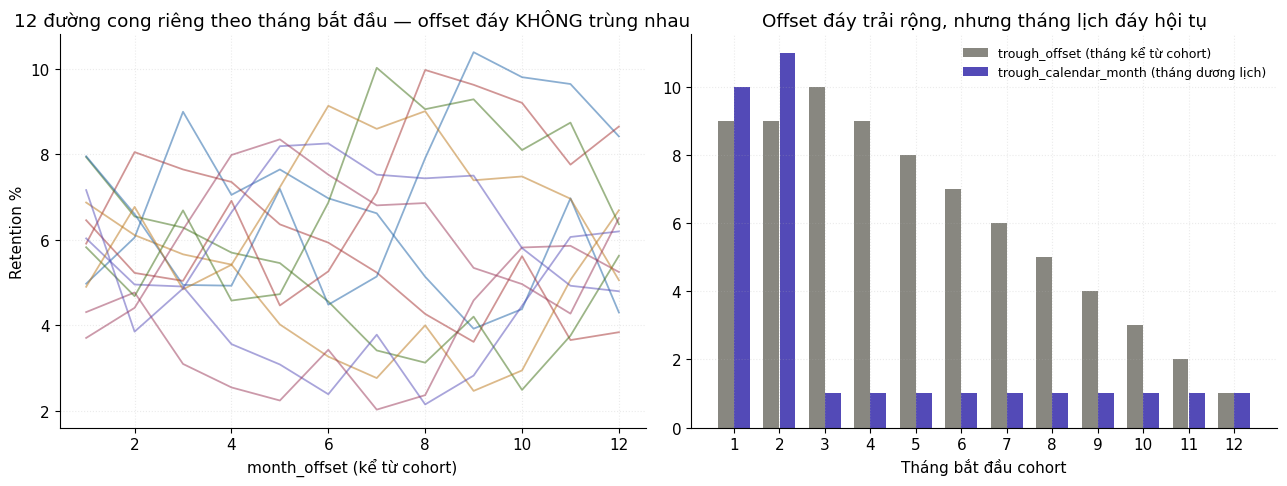

 start_cal_month  trough_offset  trough_calendar_month  trough_retention_pct
               1              9                     10                  3.92
               2              9                     11                  3.61
               3             10                      1                  2.49
               4              9                      1                  2.46
               5              8                      1                  2.14
               6              7                      1                  2.02
               7              6                      1                  4.48
               8              5                      1                  4.46
               9              4                      1                  4.58
              10              3                      1                  4.84
              11              2                      1                  3.85
              12              1                      1                  3.70

In [10]:
# Kiểm định giả thuyết "mùa vụ vs vòng đời" (nợ để lại từ phân tích trên — mục 5/6)
cohort_raw = pd.read_sql(
    "SELECT cohort_month, month_offset, cohort_size, n_active FROM int_cohort_first_order",
    _trino_conn,
)
cohort_raw["cohort_month"] = pd.to_datetime(cohort_raw["cohort_month"])
cohort_raw["start_cal_month"] = cohort_raw["cohort_month"].dt.month

by_start = (
    cohort_raw[cohort_raw["month_offset"].between(1, 12)]
    .groupby(["start_cal_month", "month_offset"])[["n_active", "cohort_size"]]
    .sum()
    .reset_index()
)
by_start["retention_pct"] = by_start["n_active"] * 100.0 / by_start["cohort_size"]

trough_rows = []
for m in range(1, 13):
    sub = by_start[by_start["start_cal_month"] == m]
    trough = sub.loc[sub["retention_pct"].idxmin()]
    offset = int(trough["month_offset"])
    cal_month = ((m - 1 + offset) % 12) + 1
    trough_rows.append({
        "start_cal_month": m, "trough_offset": offset,
        "trough_calendar_month": cal_month, "trough_retention_pct": round(float(trough["retention_pct"]), 2),
    })
trough_df = pd.DataFrame(trough_rows)

ang = 2 * np.pi * (trough_df["trough_calendar_month"] - 1) / 12
R = np.sqrt(np.cos(ang).mean() ** 2 + np.sin(ang).mean() ** 2)
circular_std_deg = np.degrees(np.sqrt(-2 * np.log(R))) if R > 0 else float("inf")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for m in range(1, 13):
    sub = by_start[by_start["start_cal_month"] == m].sort_values("month_offset")
    ax1.plot(sub["month_offset"], sub["retention_pct"], alpha=0.5, lw=1.3,
             color=PALETTE[(m - 1) % len(PALETTE)])
ax1.set_xlabel("month_offset (kể từ cohort)")
ax1.set_ylabel("Retention %")
ax1.set_title("12 đường cong riêng theo tháng bắt đầu — offset đáy KHÔNG trùng nhau")

ax2.bar(trough_df["start_cal_month"] - 0.18, trough_df["trough_offset"], width=0.35,
        color=C_GRAY, label="trough_offset (tháng kể từ cohort)")
ax2.bar(trough_df["start_cal_month"] + 0.18, trough_df["trough_calendar_month"], width=0.35,
        color=C_ACCENT, label="trough_calendar_month (tháng dương lịch)")
ax2.set_xlabel("Tháng bắt đầu cohort")
ax2.set_xticks(range(1, 13))
ax2.set_title("Offset đáy trải rộng, nhưng tháng lịch đáy hội tụ")
ax2.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

print(trough_df.to_string(index=False))
print(f"\nstd(trough_offset) = {trough_df['trough_offset'].std():.2f} tháng "
      f"(range {trough_df['trough_offset'].min()}-{trough_df['trough_offset'].max()}) -> KHÔNG hội tụ")
print(f"mode(trough_calendar_month) = {trough_df['trough_calendar_month'].mode().tolist()} "
      f"| {(trough_df['trough_calendar_month']==1).sum()}/12 nhóm đáy đúng Tháng 1")
print(f"circular std(trough_calendar_month) = {circular_std_deg:.1f}° (~{circular_std_deg/30:.2f} tháng) -> hội tụ chặt")

Đáy retention là hiệu ứng MÙA VỤ, không phải vòng đời khách hàng: 10/12 nhóm cohort (83%) có đáy rơi đúng Tháng 1 dương lịch, dù offset kể từ ngày mua đầu trải rộng 1-10 tháng tùy tháng bắt đầu.